# Temporal Convolution Netword (TCN) driven Exploratory Data Analysis (EDA)

The purpose of this EDA is to describe the statistical properties of the time series, but also to choose the best data transformations, preprocessing strategies, and architectural choices for the downstream TCN.

---
## Dataset Import and Description

The five benchmark datasets being explored consist of a univariate time series indexed by time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# loading helper
def load_and_preprocess(file, date_col=None):
    df = pd.read_csv(file)
    if date_col and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
    return df

# load datasets
data_folder = "../data/" # Expects current folder structure to be mantained in order to find the datasets
df_electricity = load_and_preprocess(data_folder+'electricity.csv', 'date')
df_solar = load_and_preprocess(data_folder+'solar.csv', 'date')
df_traffic = load_and_preprocess(data_folder+'traffic.csv') # No date column in dataset, uses hours_from_start
df_volatility = load_and_preprocess(data_folder+'volatility.csv', 'date')
df_wind = load_and_preprocess(data_folder+'wind.csv', 'date')


# Configuration based on dataset format
configs = {
  "electricity": {"df": df_electricity, "id_target": "MT_001", "id_col": "id", "target_col": "power_usage", "date_col": "date"},
  "solar": {"df": df_solar, "id_target": 0, "id_col": "id", "target_col": "power_mw", "date_col": "date"},
  "traffic": {"df": df_traffic, "id_target": 400000, "id_col": "id", "target_col": "occupancy", "date_col": "hours_from_start"},
  "volatility": {"df": df_volatility, "id_target": ".AEX", "id_col": "Symbol", "target_col": "log_vol", "date_col": "date"},
  "wind": {"df": df_wind, "id_target": "AT", "id_col": "id", "target_col": "power_output", "date_col": "date"}
}

series_dict = {}

for name, cfg in configs.items():
    subset = cfg['df'][cfg['df'][cfg['id_col']] == cfg['id_target']].copy()
    subset = subset.sort_values(cfg['date_col'])
    subset = subset.set_index(cfg['date_col'])
    series_dict[name] = subset[cfg['target_col']]

First of all, we can explore some useful indicators among the series each dataset hold. Here we count how many time series each dataset stores and characteristics of the time series themselves:

In [4]:
results = []

for name, cfg in configs.items():
    df = cfg['df']
    id_col = cfg['id_col']
    target_col = cfg['target_col']
    
    # group by ID and calculate stats for each individual series
    per_series_stats = df.groupby(id_col)[target_col].agg(['count', 'mean', 'std', 'min', 'max'])
    
    # calculate the Average of Averages for this dataset
    meta_stats = {
        'dataset': name,
        'num_unique_series': len(per_series_stats),
        'avg_series_length': per_series_stats['count'].mean(),
        'std_series_length': per_series_stats['count'].std(), # Variation in length
        'avg_mean': per_series_stats['mean'].mean(),
        'avg_std': per_series_stats['std'].mean(),
        'avg_min': per_series_stats['min'].mean(),
        'avg_max': per_series_stats['max'].mean()
    }
    results.append(meta_stats)

df_meta_summary = pd.DataFrame(results).set_index('dataset')
print("--- Meta-Analysis: Average Indicators Across All Series ---")
print(df_meta_summary.round(2))

--- Meta-Analysis: Average Indicators Across All Series ---
             num_unique_series  avg_series_length  std_series_length  \
dataset                                                                
electricity                369            5956.83             298.06   
solar                      137           52560.00               0.00   
traffic                    963            4151.00               0.00   
volatility                  31            4898.45             840.79   
wind                        28           10957.00               0.00   

             avg_mean  avg_std  avg_min  avg_max  
dataset                                           
electricity    613.81   261.16     1.04  1414.32  
solar            6.35     9.20     0.00    34.18  
traffic          0.05     0.04     0.00     0.41  
volatility      -9.73     0.97   -13.46    -5.05  
wind             0.12     0.07     0.00     0.26  


We can also inspect a single time series per dataset:

In [5]:
# summary helper
def summarize_ts(ts):
    return {
    'start': ts.index.min(),
    'end': ts.index.max(),
    'n_obs': ts.shape[0],
    'missing_%': ts.isna().mean() * 100,
    'mean': ts.mean(),
    'std': ts.std(),
    'min': ts.min(),
    'max': ts.max()
    }

summary_list = []
for name, ts in series_dict.items():
    stats = summarize_ts(ts)
    stats['dataset'] = name
    summary_list.append(stats)

df_eda_summary = pd.DataFrame(summary_list).set_index('dataset')
print(df_eda_summary[['n_obs', 'mean', 'std', 'min', 'max', 'missing_%']])

             n_obs       mean        std        min        max  missing_%
dataset                                                                  
electricity   6000   4.656885   5.842070   0.000000  34.581218        0.0
solar        52560  13.573475  17.611179   0.000000  58.850000        0.0
traffic       4151   0.049574   0.026267   0.005383   0.352417        0.0
volatility    5459  -9.682930   1.018837 -13.355362  -5.472597        0.0
wind         10957   0.126157   0.060725   0.000000   0.255319        0.0


We are also interested in knowing the time intervals between subsequent observations in the examined time series:

In [6]:
granularity_report = []

for name, ts in series_dict.items():
    # difference between subsequent index entries
    deltas = ts.index.to_series().diff().dropna()
    
    # Minimal Fix: Convert numeric traffic deltas (hours) to Timedelta objects 
    # so they print in the same "0 days 01:00:00" format as the others.
    if name == 'traffic':
        deltas = pd.to_timedelta(deltas, unit='h')

    mode_delta = deltas.mode()[0]
    is_regular = (deltas == mode_delta).all()
    max_gap = deltas.max()

    granularity_report.append({
        'Dataset': name,
        'Inferred Frequency': mode_delta,
        'Is Regular': is_regular,
        'Max Gap Found': max_gap,
        'Total Gaps': (deltas != mode_delta).sum(),
        'n_obs': len(ts) # Added for the meta-analysis context
    })

df_granularity = pd.DataFrame(granularity_report).set_index('Dataset')
print(df_granularity)

# Visualizing gaps for the non regular dataset
if not df_granularity['Is Regular'].all():
    # Find all irregular datasets
    irregular_datasets = df_granularity[df_granularity['Is Regular'] == False].index
    for ds in irregular_datasets:
        print(f"\nDistribution of time deltas for {ds}:")
        # Ensure we use the converted deltas for the value_counts display
        d = series_dict[ds].index.to_series().diff().dropna()
        if ds == 'traffic': d = pd.to_timedelta(d, unit='h')
        print(d.value_counts().head())

            Inferred Frequency  Is Regular   Max Gap Found  Total Gaps  n_obs
Dataset                                                                      
electricity    0 days 01:00:00        True 0 days 01:00:00           0   6000
solar          0 days 00:10:00        True 0 days 00:10:00           0  52560
traffic        0 days 01:00:00        True 0 days 01:00:00           0   4151
volatility     1 days 00:00:00       False 7 days 00:00:00        1148   5459
wind           1 days 00:00:00        True 1 days 00:00:00           0  10957

Distribution of time deltas for volatility:
date
1 days    4310
3 days    1063
4 days      30
5 days      28
2 days      25
Name: count, dtype: int64


We can thus see that each dataset contains a large number of time series, each holding numerous observatons. As expected, there are no missing values.

A different challenge arises regarding *Volatility* dataset: it seems that observations are not taken only at regular intervals, but gaps of more than one day exist along the series. This could be because finantial markets are closed on weekends and holidays, thus no measurements can be taken in those days. This irregular patterns could hinder the TCN from learning correct temporal patterns, so to take into account changes that happen during these "unseen" days we could fill in the unsampled days to ensure that weekly patterns can be learned correctly.

After filling in the missing days in the volatility time series, we could consider to use the following windows for TCN receptive fields:
| Dataset     | Step Size | Daily Observations  | TCN Receptive Field Proposal |
|-------------|-----------|---------------------|------------------------------|
| Electricity | 1 Hour    | 24                  | 168 steps (1 week)           |
| Solar       | 10 Min    | 144                 | 144–288 steps (1–2 days)     |
| Traffic     | 1 Hour    | 24                  | 168 steps (1 week)           |
| Volatility  | 1 Day     | 1                   | 30–60 steps (1–2 months)     |
| Wind        | 1 Day     | 1                   | 30–90 steps (1 quarter)      |

We will try to valideate these choices further below in the EDA.

---
## Temporal Dependencies and Receptive Field Requirements

Autocorrelation analysis can be used to estimate the minimum receptive field that the TCN must cover.

Significant autocorrelation at large lags implies that:
- the dilation schedule must expand accordingly;
- shallow networks may fail to capture long-range dependencies.

The largest lag with significant correlation can be interpreted as a lower bound on the required temporal context.

Below, autocorrelation plots are computed for each time series, bounding the temporal lag in function of the time windows extracted above:

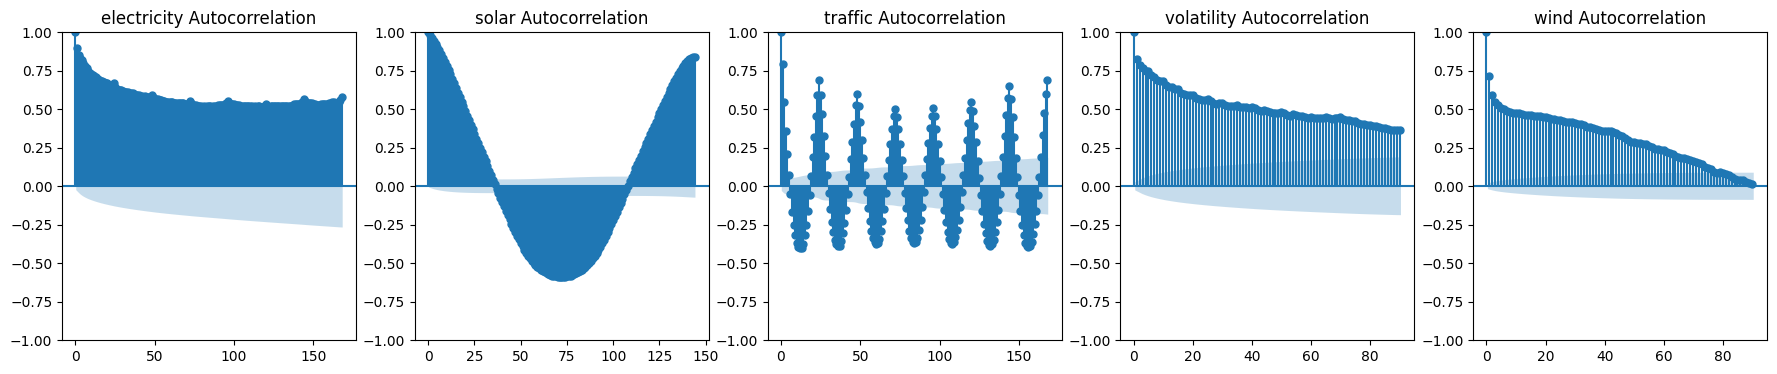

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
lags = [168, 144, 168, 90, 90]
for i, (name, ts) in enumerate(series_dict.items()):
    plot_acf(ts.dropna(), lags=lags[i], ax=axes[i], title=f"{name} Autocorrelation")

* **Traffic** (Hourly Granularity): Shows the most distinct seasonality with sharp, significant peaks exactly every 24 lags. To capture the daily pattern, the receptive field must be at least 24. To capture the weekly rhythm observed, a receptive field of 168 would be ideal.

* **Solar** (10-Minute Granularity): Displays a wide parabolic wave that crosses into negative correlation and returns to a high positive peak at Lag 144. TCN Impact: Because $144\ lags × 10\ minutes=24\ hours$, the TCN requires a much larger receptive field (144 steps) just to see one day of history. Architectural dilations should be scaled up significantly compared to the hourly datasets.

* **Electricity** (Hourly Granularity): Shows high persistence, as correlation stays above 0.5 for a full week. While the decay is slow, there are subtle local peaks every 24 lags, confirming it shares the hourly granularity of Traffic but with a much stronger dependency on recent history. The model will need to balance a large receptive field to handle the persistence, with the ability to detect the subtle 24-hour cycles.

* **Volatility** (Daily Granularity - Long Memory): Exhibits a very slow decay. Even at Lag 90 (3 months of data), the correlation remains significantly above the noise threshold (~0.35). Being a Long Memory series, the TCN will require deep layers and high dilation factors to ensure the filters can reach back several months to identify volatility regimes.

* **Wind** (Daily Granularity - Stochastic): Shows a rapid drop in the first few lags followed by a very gradual decline that reaches the significance threshold around Lag 80. The steep initial drop suggests that the immediate past is highly informative, but the long-term trend is weak. A TCN with a larger kernel size might help smooth out the high-frequency noise seen in the distribution plots.

---
## Global and Local Temporal Structure

We plot a visualization of the raw time series to identify large-scale patterns such as:
- long-term trends;
- visible seasonal cycles;
- extreme events.

This step provides a high-level understanding of the signal, but is not sufficient as TCN depend primarily on local temporal behavior within fixed windows: local stationarity within windows is more relevant than global stationarity.

The Rolling Mean is also plotted over the time series, tuning the window size based on results from autocorrelation plots to quantitatively find a starting point for the later stages of the method developement.

In [8]:
def plot_stability(ts, name, window=128):
    plt.figure(figsize=(12, 3))
    ts_roll_mean = ts.rolling(window).mean()
    ts_roll_std = ts.rolling(window).std()
    
    plt.plot(ts, alpha=0.3, label='Raw')
    plt.plot(ts_roll_mean, label='Rolling Mean', color='red')
    plt.fill_between(ts.index, ts_roll_mean - ts_roll_std, ts_roll_mean + ts_roll_std, color='red', alpha=0.1)
    plt.title(f"{name.upper()}: Local Stability (Window={window})")
    plt.legend()
    plt.show()

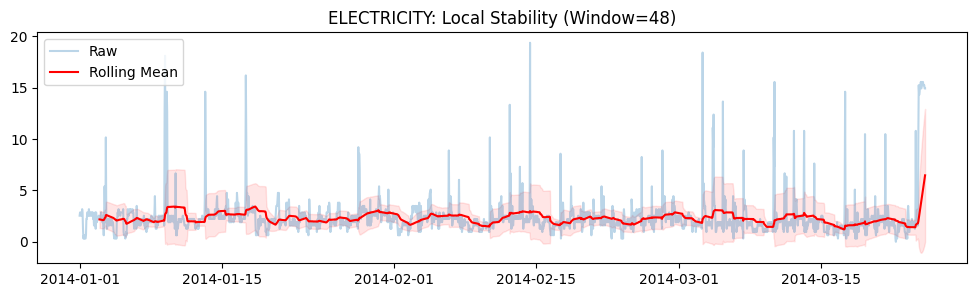

In [20]:
plot_stability(series_dict["electricity"].head(2000), "electricity", window=48) # 168 observations every week

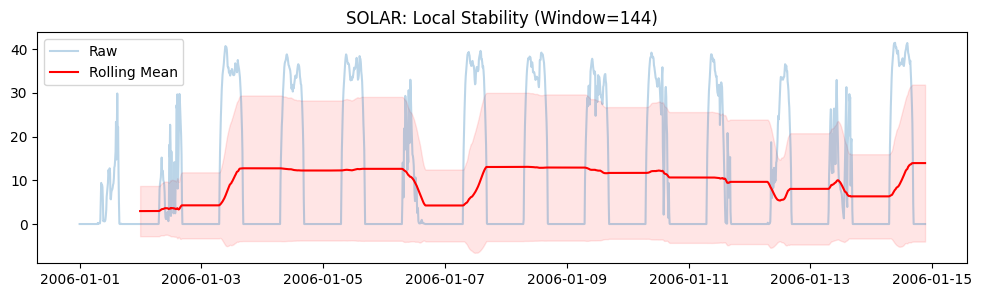

In [10]:

plot_stability(series_dict["solar"].head(2000), "solar", window=144) # 144 observations every day

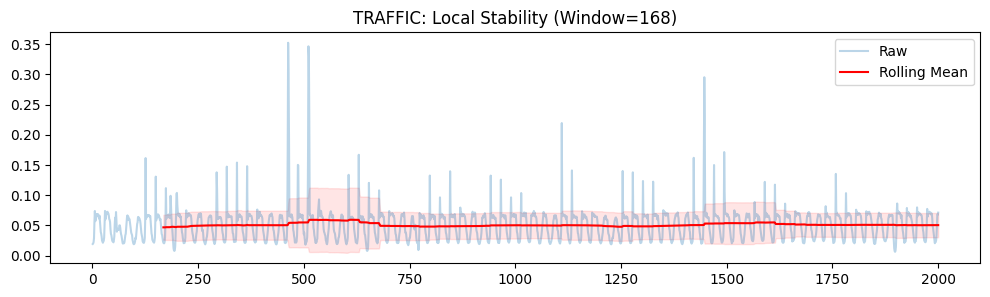

In [11]:
plot_stability(series_dict["traffic"].head(2000), "traffic", window=168) # confirms hypothesis from ACF plot, multiples of 24 are good window sizes (168: one week)

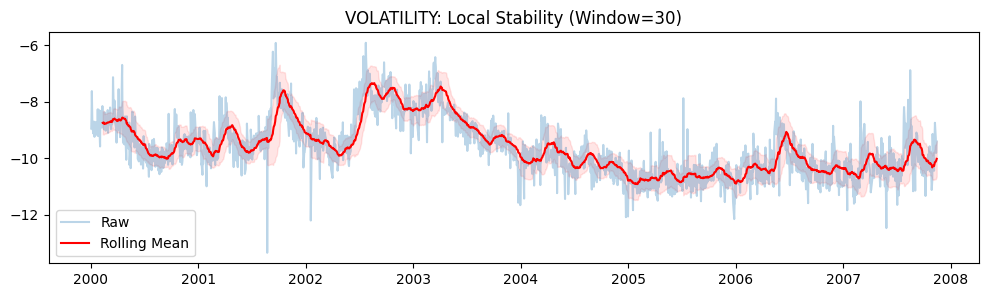

In [12]:
plot_stability(series_dict["volatility"].head(2000), "volatility", window=30) # 30 : around one week

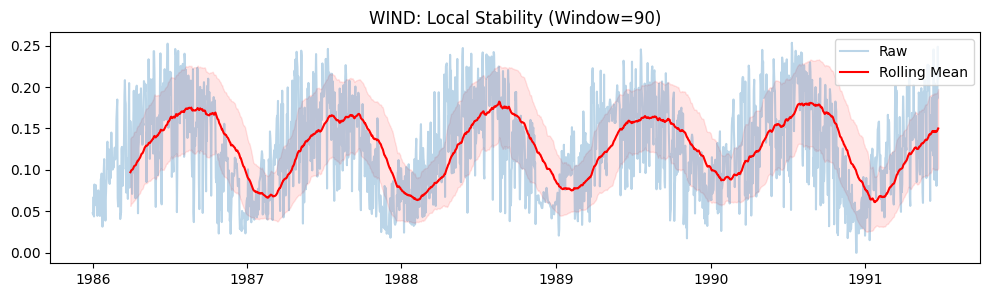

In [ ]:
plot_stability(series_dict["wind"].head(2000), "wind", window=90) # 90 : 3 months

* **Electricity**: The rolling mean is stable, but the signals shows extreme, sparse spikes. using RobustScaler to ignore these spikes during normalization could improve performance.

* **Solar**: The rolling mean follows a clear periodic wave. There is no long-term drift, but the variance is high during the day and zero at night.

* **Traffic**: Stable pattern, with only a few outliers. The periodic pattern is consistent over the examined snippet.

* **Volatility**: This is the only series showing significant regime changes. The mean shifts drastically between 2002 (high) and 2005 (low). A global scaler may fail here, we probably should Differenciate the series before using them.

* **Wind**: Shows a slow, seasonal-style oscillation in the mean. The local variance (pink shaded area) remains relatively constant throughout.

---
In the following, we adress the long-term shifts in the Volatility dataset applying First-Order Differenciation to stabilize the mean and compare the results:

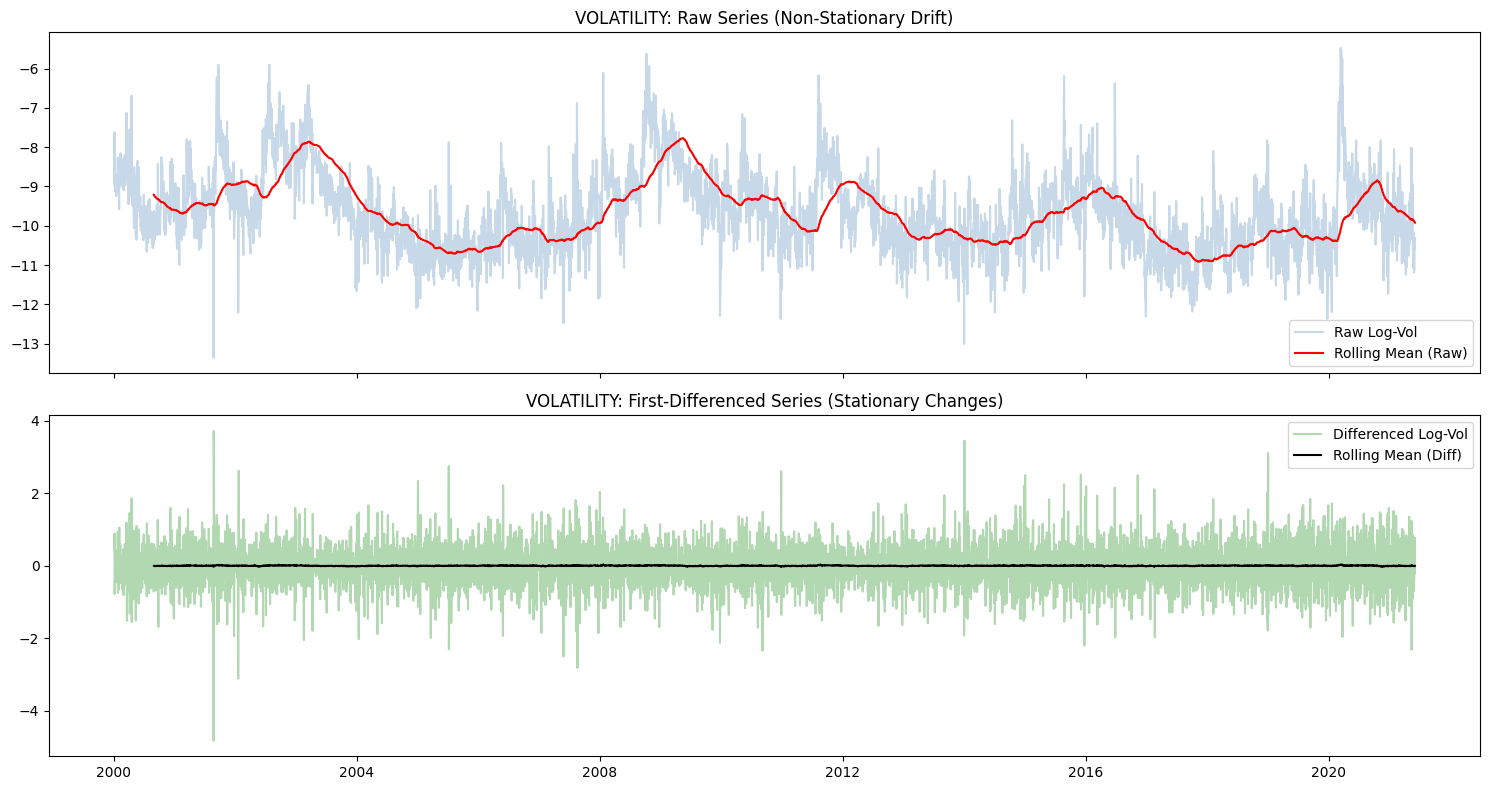

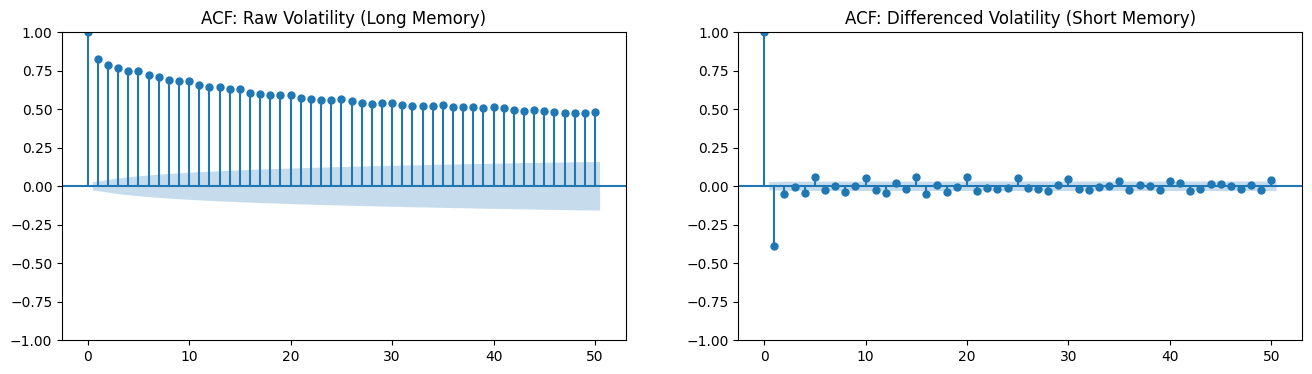

In [14]:
vol_raw = series_dict['volatility']
vol_diff = vol_raw.diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(vol_raw, alpha=0.3, color='steelblue', label='Raw Log-Vol')
ax1.plot(vol_raw.rolling(168).mean(), color='red', label='Rolling Mean (Raw)')
ax1.set_title("VOLATILITY: Raw Series (Non-Stationary Drift)")
ax1.legend()

ax2.plot(vol_diff, alpha=0.3, color='green', label='Differenced Log-Vol')
ax2.plot(vol_diff.rolling(168).mean(), color='black', label='Rolling Mean (Diff)')
ax2.set_title("VOLATILITY: First-Differenced Series (Stationary Changes)")
ax2.legend()

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(vol_raw.dropna(), lags=50, ax=ax1, title="ACF: Raw Volatility (Long Memory)")
plot_acf(vol_diff.dropna(), lags=50, ax=ax2, title="ACF: Differenced Volatility (Short Memory)")
plt.show()

The results for the differenciated time series are much more regular, even though they reduce to something similiar to noise. We can consider using this transformation on the dataset before passing it to the models for training.

---
## Seasonal Operationalization

In our TCNs, we must decide wether we want to encode time as a feature or let the TCN learn it via deep filters.

Dataset     | Seasonality             | Encoding         | Motivation
------------|-------------------------|------------------|--------------------------------
Electricity |	Diurnal & Weekly      |Encode (Sin/Cos)  | Electricity usage is tied to human routines along the week.
Solar	    | Diurnal (Daily)	      | Encode (Sin/Cos) | Hard zero-values at night are easier for the model if it has an explicit clock input.
Traffic	    | Daily & Weekly	      | Fourier Features | High complexity seasonality is better served by external encodings than deep networks alone.
Wind	    | Weak, Stochastic    	  | None             | The TCN will act as a noise-reducing filter.   
Volatility	| None (Structural Trend) |	Differencing     | Seasonal encoding of finantial volatility looks like noise; Differencing removes the trend and stabilizes the mean.

---
## Value Distribution and Scaling Implications

Convolutional neural networks are sensitive to the scale and distribution of inputs. This section examines:
- skewness and heavy tails;
- presence of extreme values;
- bounded or strictly positive domains.

The goal is to determine whether transformations such as logarithmic scaling, robust normalization, or per-window standardization are required to ensure stable gradient flow during training.

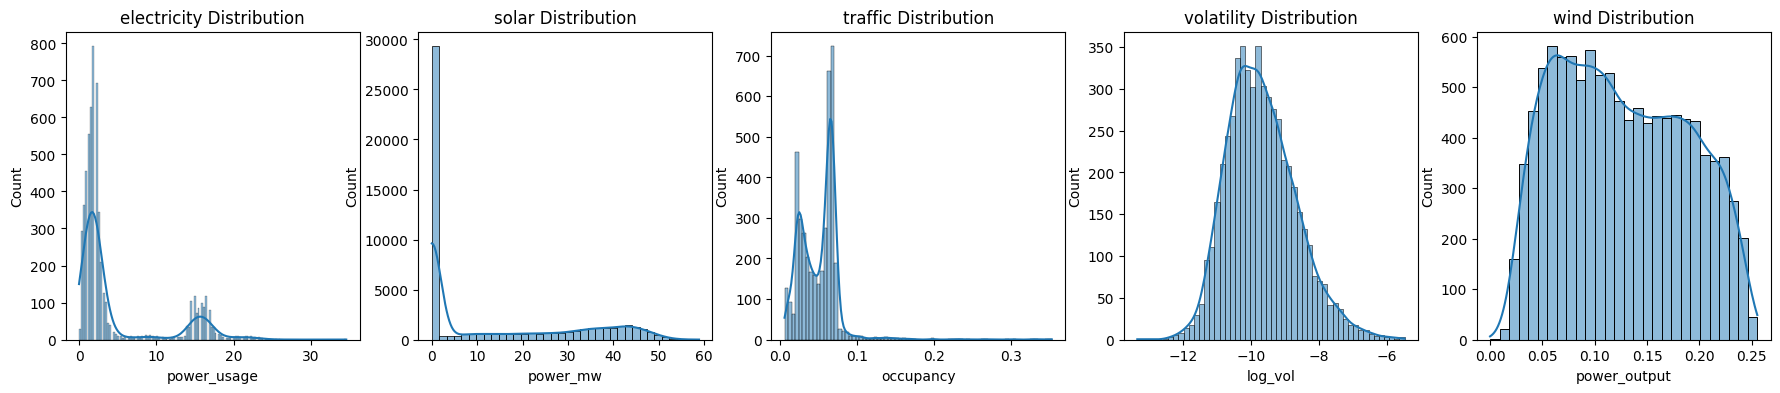

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (name, ts) in enumerate(series_dict.items()):
    sns.histplot(ts, kde=True, ax=axes[i])
    axes[i].set_title(f"{name} Distribution")

* **Electricity (Heavy-Tailed)**: The distribution is bimodal with a long tail to the right. Standard MSE loss will be skewed by the outliers, so solutions like Huber Loss can be utilized for more robust training.

* **Solar (Zero-Inflated)**: As expected, we can see a spike at the value $0.0$. The use of a ReLU or similiar functions on the final layer ensures the model never predicts negative sunlight.

* **Traffic (Bimodal)**: We can distinguish clear peaks representing free flow of cars and congested states. The TCN needs enough hidden channels to distinguish between these two regimes.

* **Volatility (Gaussian)**: The log_vol is almost perfectly normally distributed. This is ideal for neural networks. Standard MSE loss and should work.

* **Wind (Skewed/Bounded)**: Most values cluster between $0.05$ and $0.15$, capped at $\sim 0.25$. the use of standardization can be appropriate.

In all datasets, **scaling** the target variables will probably improve the convergence of the methods. In particular, data scaling will provide benefits to the series that show abrupt peaks, like traffic and electricity.

---
We can also plot the distribution of the differenced Volatility, as we discussed that it forms a better dataset compared to the original, semi-random values:

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
C:\Users\test1\AppData\Local\Temp\ipykernel_11452\3771504971.py:11: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_xlabel("Change in log_vol ($\Delta$)")


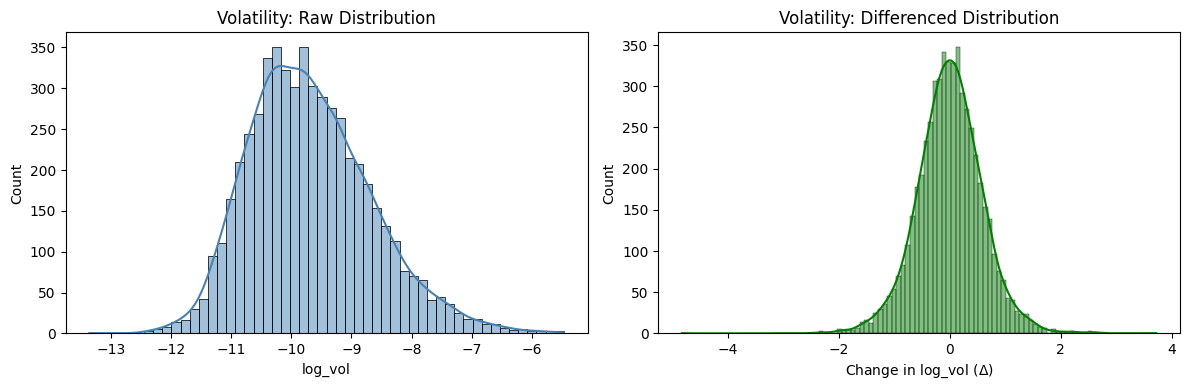

Raw Volatility Mean: -9.6829
Differenced Volatility Mean: -0.0002


In [21]:
vol_raw = series_dict['volatility']
vol_diff = vol_raw.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(vol_raw, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Volatility: Raw Distribution")
axes[0].set_xlabel("log_vol")

sns.histplot(vol_diff, kde=True, ax=axes[1], color='green')
axes[1].set_title("Volatility: Differenced Distribution")
axes[1].set_xlabel("Change in log_vol ($\Delta$)")

plt.tight_layout()
plt.show()

print(f"Raw Volatility Mean: {vol_raw.mean():.4f}")
print(f"Differenced Volatility Mean: {vol_diff.mean():.4f}")

We can notice that the differenced distribution is perfectly centered at $0.0$. This will ensure that the TCNs' weights will not be biased by the absolute magnitude of the input.\
The differenced distribution is also tighter wrt the original data and resembles a Gaussian distribution, indicating that the noise is now the primary signal.

The range of the differenced data is significantly smaller, allowing for much more stable gradient descent during training, as the activations in the causal convolution layers are less likely to saturate.

---
## Dataset-Specific Recap and Preprocessing Recommendations

This section summarizes the main characteristics identified during the exploratory analysis for each dataset and proposes preprocessing strategies aligned with the observed data properties and the requirements of Temporal Convolutional Networks (TCNs).

### ELECTRICITY

**Observed characteristics**
- Multiple parallel time series with long history and regular hourly sampling.
- Strong and stable daily and weekly seasonality.
- Mild long-term trend with relatively stable variance.

**Implications for TCNs**
- Long and stable seasonal patterns require a receptive field covering at least one week.
- Seasonality is strong enough to be learned implicitly but may benefit from explicit handling.

**Proposed preprocessing**
- Optional STL decomposition with residual + seasonal channels.
- Global standardization (StandardScaler) applied per series.
- Input windows of ~168 time steps (1 week); multiples of 24 can also work.
- No differencing required due to moderate trend.

### SOLAR

**Observed characteristics**
- High-frequency data with strict daily periodicity.
- Zero-valued nighttime observations.
- Strongly bounded and non-negative signal.
- Minimal long-term trend.

**Implications for TCNs**
- Deterministic daily seasonality dominates the signal.
- Sharp transitions (sunrise/sunset) can challenge convolution filters.

**Proposed preprocessing**
- MinMax scaling to preserve bounded structure.
- Optional masking or separate channel for nighttime periods.
- Input windows spanning 1–2 full daily cycles (144–288 steps).
- No detrending required, seasonality can be learned implicitly.

### TRAFFIC

**Observed characteristics**
- Large number of parallel sensor time series.
- Strong intraday and weekly seasonality.
- Moderate noise and occasional local disruptions.

**Implications for TCNs**
- Multi-scale seasonality requires sufficiently deep dilation stacks.
- Cross-series heterogeneity suggests per-series normalization.

**Proposed preprocessing**
- Global or per-series standardization.
- Input windows covering one week (168 steps); multiple of 24 can also work.
- Optional removal of low-frequency trend if present.
- No differencing required in most cases.

### VOLATILITY

**Observed characteristics**
- Daily financial time series with irregular gaps.
- No clear seasonality; high stochastic variability.
- Frequent regime shifts and volatility clustering.
- Strong non-stationarity in variance.

**Implications for TCNs**
- Fixed seasonal encoding is not meaningful.
- Models must focus on short to medium term dependencies.
- Sensitivity to scale and outliers is critical.

**Proposed preprocessing**
- Fill in missing values; could also consider 5 day seasonality (ignore weekends).
- Log or variance-stabilizing transformations if applicable.
- Input windows of 30–60 steps.
- Optional differencing to reduce trend-like effects.

### WIND

**Observed characteristics**
- Daily observations with long historical span.
- Weak and unstable seasonality.
- High short-term variability driven by weather regimes.
- Slow-moving climate-related trends.

**Implications for TCNs**
- Fixed seasonal encoding provides limited benefit.
- Local autoregressive structure dominates predictability.
- Longer windows help capture regime persistence.

**Proposed preprocessing**
- Standardization or robust scaling.
- Input windows of 30–90 days.
- No explicit seasonal removal.
- Optional detrending if long-term drift dominates local dynamics.